In [1]:
pip install pandas numpy matplotlib seaborn arch statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from arch import arch_model


In [3]:
# Load datasets
stocks_df = pd.read_csv("C:\\Users\\Dell\\Downloads\\NIFTY\\stocks_df.csv")
indexes_df = pd.read_csv("C:\\Users\\Dell\\Downloads\\NIFTY\\indexes_df.csv")
nse_indexes = pd.read_csv("C:\\Users\\Dell\\Downloads\\NIFTY\\nse_indexes.csv")

print(stocks_df.head())
print(indexes_df.head())
print(nse_indexes.head())


         Date      Stock   Open   High    Low  Close   Volume  Change Pct
0  2013-01-02  20MICRONS  80.35  80.55  77.50  77.80  1088880       -3.23
1  2013-01-03  20MICRONS  78.58  79.78  76.00  76.40   590180       -1.80
2  2013-01-04  20MICRONS  76.50  77.25  75.50  75.83   380850       -0.75
3  2013-01-07  20MICRONS  76.88  78.00  74.00  74.90  1144204       -1.23
4  2013-01-08  20MICRONS  74.97  75.97  74.25  75.28   605020        0.51
              Symbol
0  NIFTY 50 Pre Open
1           NIFTY 50
2      NIFTY NEXT 50
3    NIFTY100 LIQ 15
4         NIFTY BANK
         Date     Index     Open     High     Low   Close  Volume Currency
0  1995-11-06  NIFTY 50  1001.53  1001.53  988.92  988.92       0      INR
1  1995-11-07  NIFTY 50   987.17   987.17  977.05  978.22       0      INR
2  1995-11-08  NIFTY 50   976.28   976.28  962.98  964.01       0      INR
3  1995-11-09  NIFTY 50   960.32   960.32  952.13  953.07       0      INR
4  1995-11-10  NIFTY 50   951.93   951.93  946.00  948.

In [4]:
# Convert Date column to datetime
nse_indexes['Date'] = pd.to_datetime(nse_indexes['Date'])

# Filter NIFTY 50 index
nifty50 = nse_indexes[nse_indexes['Index'] == 'NIFTY 50'].copy()

# Sort by date
nifty50.sort_values('Date', inplace=True)

# Check data
nifty50.head()


,Date,Index,Open,High,Low,Close,Volume,Currency
0,1995-11-06,NIFTY 50,1001.53,1001.53,988.92,988.92,0,INR
1,1995-11-07,NIFTY 50,987.17,987.17,977.05,978.22,0,INR
2,1995-11-08,NIFTY 50,976.28,976.28,962.98,964.01,0,INR
3,1995-11-09,NIFTY 50,960.32,960.32,952.13,953.07,0,INR
4,1995-11-10,NIFTY 50,951.93,951.93,946.00,948.82,0,INR


In [5]:
# Compute log returns
nifty50['log_return'] = np.log(
    nifty50['Close'] / nifty50['Close'].shift(1)
)

# Drop NaN values
returns = nifty50['log_return'].dropna()

returns.head()


1   -0.010879
2   -0.014633
3   -0.011413
4   -0.004469
5   -0.033828
Name: log_return, dtype: float64

In [6]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(returns)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Returns are stationary ✔")
else:
    print("Returns are non-stationary ❌")


ADF Statistic: -18.32409848635861
p-value: 2.2627266401570203e-30
Returns are stationary ✔


In [7]:
from arch import arch_model

arch_mod = arch_model(
    returns,
    mean='Zero',
    vol='ARCH',
    p=1
)

arch_res = arch_mod.fit(disp='off')
print(arch_res.summary())


                        Zero Mean - ARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                18594.9
Distribution:                  Normal   AIC:                          -37185.9
Method:            Maximum Likelihood   BIC:                          -37172.3
                                        No. Observations:                 6529
Date:                Sat, Feb 21 2026   Df Residuals:                     6529
Time:                        17:14:25   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.4424e-04  6.196e-06     23.278 7.407e-120 [1.

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002219. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [8]:
garch_mod = arch_model(
    returns,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

garch_res = garch_mod.fit(disp='off')
print(garch_res.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                19266.8
Distribution:                  Normal   AIC:                          -38527.6
Method:            Maximum Likelihood   BIC:                          -38507.3
                                        No. Observations:                 6529
Date:                Sat, Feb 21 2026   Df Residuals:                     6529
Time:                        17:14:35   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      4.4419e-06  1.548e-13  2.869e+07      0.000 [4.

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002219. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [9]:
egarch_mod = arch_model(
    returns,
    mean='Zero',
    vol='EGARCH',
    p=1,
    q=1
)

egarch_res = egarch_mod.fit(disp='off')
print(egarch_res.summary())


                       Zero Mean - EGARCH Model Results                       
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:                19269.3
Distribution:                  Normal   AIC:                          -38532.5
Method:            Maximum Likelihood   BIC:                          -38512.2
                                        No. Observations:                 6529
Date:                Sat, Feb 21 2026   Df Residuals:                     6529
Time:                        17:14:43   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.1453  4.325e-02     -3.360  7.796e-04 [ -0.2

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002219. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


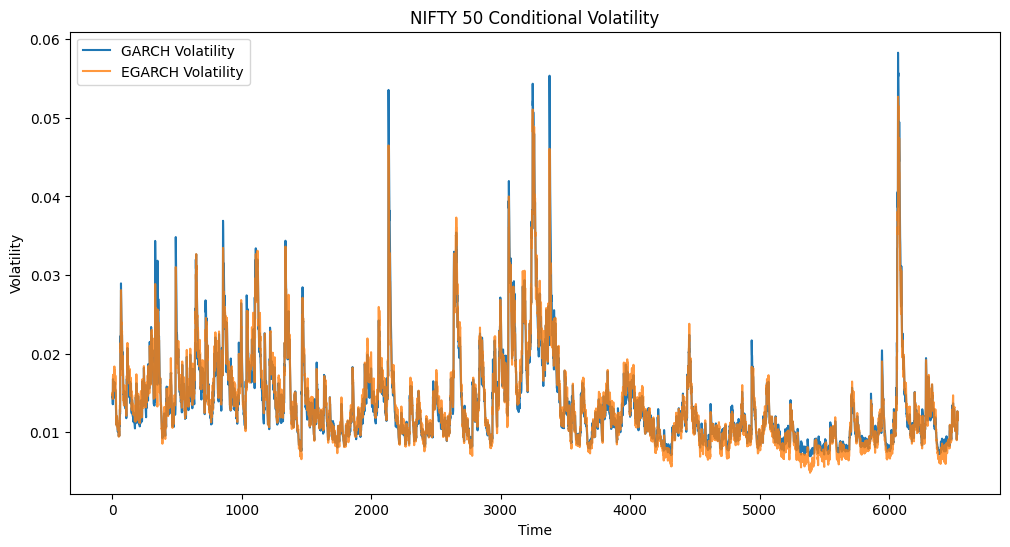

In [10]:
plt.figure(figsize=(12,6))

plt.plot(garch_res.conditional_volatility, label='GARCH Volatility')
plt.plot(egarch_res.conditional_volatility, label='EGARCH Volatility', alpha=0.8)

plt.title("NIFTY 50 Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()


In [11]:
comparison = pd.DataFrame({
    'Model': ['ARCH(1)', 'GARCH(1,1)', 'EGARCH(1,1)'],
    'Log-Likelihood': [
        arch_res.loglikelihood,
        garch_res.loglikelihood,
        egarch_res.loglikelihood
    ],
    'AIC': [
        arch_res.aic,
        garch_res.aic,
        egarch_res.aic
    ],
    'BIC': [
        arch_res.bic,
        garch_res.bic,
        egarch_res.bic
    ]
})

comparison


,Model,Log-Likelihood,AIC,BIC
0,ARCH(1),18594.947160,-37185.894319,-37172.326301
1,"GARCH(1,1)",19266.820090,-38527.640179,-38507.288152
2,"EGARCH(1,1)",19269.264256,-38532.528512,-38512.176484


In [12]:
# Create a clean working dataframe
df = nifty50[['Date', 'Close']].copy()
df['log_return'] = returns

df = df.dropna().reset_index(drop=True)
df.head()


,Date,Close,log_return
0,1995-11-07,978.22,-0.010879
1,1995-11-08,964.01,-0.014633
2,1995-11-09,953.07,-0.011413
3,1995-11-10,948.82,-0.004469
4,1995-11-13,917.26,-0.033828


In [13]:
# Lagged returns
df['ret_lag1'] = df['log_return'].shift(1)
df['ret_lag2'] = df['log_return'].shift(2)

# Lagged squared returns (ARCH effect)
df['ret_sq_lag1'] = df['log_return'].shift(1) ** 2
df['ret_sq_lag2'] = df['log_return'].shift(2) ** 2

In [14]:
# Rolling volatility (standard deviation)
df['vol_5'] = df['log_return'].rolling(window=5).std()
df['vol_20'] = df['log_return'].rolling(window=20).std()


In [15]:
# EWMA volatility (RiskMetrics style)
df['ewma_vol'] = df['log_return'].ewm(span=20).std()


In [16]:
df['day_of_week'] = df['Date'].dt.dayofweek   # Monday=0
df['month'] = df['Date'].dt.month


In [17]:
# Define volatility regimes using rolling volatility
low_thr = df['vol_20'].quantile(0.33)
high_thr = df['vol_20'].quantile(0.66)

def assign_regime(x):
    if x < low_thr:
        return 0   # Low volatility
    elif x < high_thr:
        return 1   # Medium volatility
    else:
        return 2   # High volatility

df['vol_regime'] = df['vol_20'].apply(assign_regime)


In [18]:
# Drop missing values created by lags & rolling
df_fe = df.dropna().reset_index(drop=True)

df_fe.head()


,Date,Close,log_return,ret_lag1,ret_lag2,ret_sq_lag1,ret_sq_lag2,vol_5,vol_20,ewma_vol,day_of_week,month,vol_regime
0,1995-12-04,863.70,-0.010767,0.012622,0.019893,0.000159,0.000396,0.016561,0.014478,0.015504,0,12,2
1,1995-12-05,866.52,0.003260,-0.010767,0.012622,0.000116,0.000159,0.011638,0.014612,0.014797,1,12,2
2,1995-12-06,878.93,0.014220,0.003260,-0.010767,0.000011,0.000116,0.012000,0.015136,0.015011,2,12,2
3,1995-12-07,898.62,0.022155,0.014220,0.003260,0.000202,0.000011,0.012596,0.016169,0.015995,3,12,2
4,1995-12-08,887.12,-0.012880,0.022155,0.014220,0.000491,0.000202,0.015284,0.016319,0.015777,4,12,2


In [19]:
df_fe.describe()


,Date,Close,log_return,ret_lag1,ret_lag2,ret_sq_lag1,ret_sq_lag2,vol_5,vol_20,ewma_vol,day_of_week,month,vol_regime
count,6510,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000,6510.000000
mean,2008-12-21 05:00:23.225806336,5172.689017,0.000459,0.000459,0.000462,0.000222,0.000222,0.012059,0.013029,0.013123,2.008602,6.513825,1.010138
min,1995-12-04 00:00:00,788.150000,-0.139038,-0.139038,-0.139038,0.000000,0.000000,0.000982,0.003209,0.003998,0.000000,1.000000,0.000000
25%,2002-06-11 06:00:00,1317.787500,-0.006620,-0.006620,-0.006620,0.000011,0.000011,0.006667,0.008409,0.008477,1.000000,4.000000,0.000000
50%,2008-12-09 00:00:00,4632.125000,0.000840,0.000840,0.000847,0.000054,0.000054,0.009842,0.011072,0.011273,2.000000,7.000000,1.000000
75%,2015-07-05 06:00:00,8049.925000,0.007963,0.007963,0.007965,0.000185,0.000185,0.014882,0.015615,0.015685,3.000000,9.000000,2.000000
max,2022-01-31 00:00:00,18477.050000,0.163343,0.163343,0.163343,0.026681,0.026681,0.087063,0.057000,0.056614,6.000000,12.000000,2.000000
std,NaN,4127.157391,0.014894,0.014894,0.014896,0.000727,0.000727,0.008560,0.007136,0.006986,1.426087,3.457759,0.818564


In [20]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Target: next-day volatility (20-day rolling)
df_fe['target_vol'] = df_fe['vol_20'].shift(-1)

# Drop last row (target becomes NaN)
df_ml = df_fe.dropna().reset_index(drop=True)

df_ml[['vol_20', 'target_vol']].head()


,vol_20,target_vol
0,0.014478,0.014612
1,0.014612,0.015136
2,0.015136,0.016169
3,0.016169,0.016319
4,0.016319,0.014805


In [27]:
feature_cols = [
    'ret_lag1',
    'ret_lag2',
    'ret_sq_lag1',
    'ret_sq_lag2',
    'vol_5',
    'vol_20',
    'ewma_vol',
    'day_of_week',
    'month',
    'vol_regime'
]

X = df_ml[feature_cols]
y = df_ml['target_vol']


In [28]:
split = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)


XGBoost RMSE: 0.000980313183754747
XGBoost MAE: 0.00047532873899122294


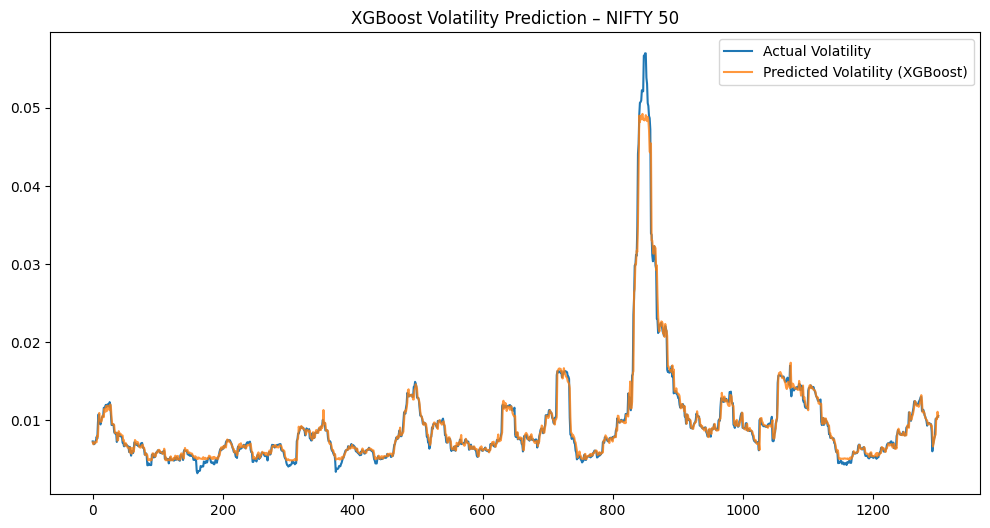

In [32]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Volatility')
plt.plot(y_pred, label='Predicted Volatility (XGBoost)', alpha=0.8)
plt.title("XGBoost Volatility Prediction – NIFTY 50")
plt.legend()
plt.show()
